Accuracy: 0.9712


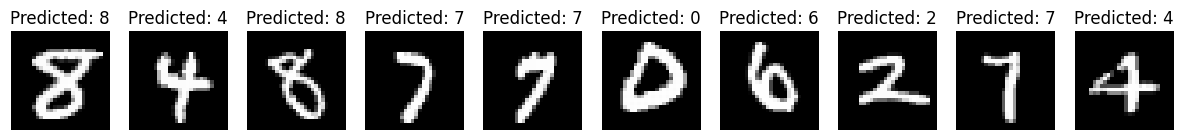

In [1]:
#image classification with the help of ann on mnist dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X, y = mnist.data, mnist.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Create and train the MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)
# Evaluate the model
accuracy = mlp.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy:.4f}')
# Predict on the test set
y_pred = mlp.predict(X_test_scaled)
# Visualize some predictions
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for i in range(10):
    axes[i].imshow(X_test.iloc[i].values.reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Predicted: {y_pred[i]}')
    axes[i].axis('off')
plt.show()

In [2]:
#ann with only numpy no other library and module 
import numpy as np
class SimpleANN:
    def __init__(self, input_size, hidden_size, output_size):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        # Initialize weights
        self.W1 = np.random.rand(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.rand(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))
    
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, z):
        return self.sigmoid(z) * (1 - self.sigmoid(z))
    
    def softmax(self, z):
        exp_z = np.exp(z - np.max(z))
        return exp_z / exp_z.sum(axis=1, keepdims=True)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.softmax(self.z2)
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        m = y_true.shape[0]
        log_likelihood = -np.log(y_pred[range(m), y_true.astype(int)])
        loss = np.sum(log_likelihood) / m
        return loss
    
    def backward(self, X, y_true):
        m = X.shape[0]
        delta2 = self.a2
        delta2[range(m), y_true.astype(int)] -= 1
        dW2 = np.dot(self.a1.T, delta2) / m
        db2 = np.sum(delta2, axis=0) / m
        
        delta1 = np.dot(delta2, self.W2.T) * self.sigmoid_derivative(self.z1)
        dW1 = np.dot(X.T, delta1) / m
        db1 = np.sum(delta1, axis=0) / m
        
        # Update weights and biases
        learning_rate = 0.01
        self.W2 -= learning_rate * dW2
        self.b2 -= learning_rate * db2
        self.W1 -= learning_rate * dW1
        self.b1 -= learning_rate * db1
    def train(self, X, y, epochs):
        for epoch in range(epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.backward(X, y)
            if (epoch + 1) % 10 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss:.4f}')
# Example usage
if __name__ == "__main__":
    # Load the MNIST dataset (using numpy for simplicity)
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1)
    X, y = mnist.data, mnist.target.astype(int)
    
    # Normalize the data
    X = X / 255.0
    
    # Split the dataset into training and testing sets
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Create and train the ANN
    input_size = X_train.shape[1]
    hidden_size = 100
    output_size = 10
    ann = SimpleANN(input_size, hidden_size, output_size)
    ann.train(X_train.values, y_train.values, epochs=100)
    # Evaluate the model
    y_pred = ann.forward(X_test.values)
    predicted_labels = np.argmax(y_pred, axis=1)
    accuracy = np.mean(predicted_labels == y_test.values)
    print(f'Accuracy: {accuracy:.4f}')
    

KeyboardInterrupt: 